# Phân tích Khám phá Dữ liệu (EDA) - Tối ưu hóa cho Mô hình LightGBM
**Thực hiện:** Nhóm nghiên cứu & mô hình hóa dữ liệu (Lớp Học máy - UTH)

## Giới thiệu
Quyết định chọn **LightGBM** làm mô hình cốt lõi mang lại những lợi thế vô cùng to lớn đối với bộ dữ liệu hành vi mua sắm tại các trung tâm thương mại (`customer_shopping_data.csv`). 

Để LightGBM phát huy tối đa sức mạnh phân nhánh cây dọc (**Leaf-wise**) và xử lý biến phân loại tối ưu gốc (**Native Categorical Features**), bước EDA này sẽ tập trung đào sâu vào các đặc thù:
1. **Đặc trưng phân loại (Categorical Features):** Khám phá số lượng nhóm độc nhất (Cardinality) để thiết lập ép kiểu dữ liệu danh mục (`category` dtype) thay vì One-Hot.
2. **Phân phối biến mục tiêu Doanh thu (`Sales_Revenue`):** Doanh thu được tính bằng $Quantity \times Price$. Chúng ta sẽ phân tích mức độ lệch phải (Skewness) và sự cần thiết của phép biến đổi Logarit.
3. **Phân khúc tuổi tác (`age`):** Phân tích ảnh hưởng của tuổi tác tới hành vi chi tiêu.
4. **Yếu tố thời gian chuyên sâu (`invoice_date`):** Phân tích xu hướng dài hạn (Trend) từ 2021-2023, tính chu kỳ theo tháng và các ngày trong tuần.
5. **Tương tác đặc trưng chéo (Feature Interaction):** Phân tích các cặp biến tương tác như `category` vs `payment_method` và `shopping_mall` vs `category`.
6. **Khảo sát thuộc tính định danh (`customer_id`):** Xác định tần suất xuất hiện của khách hàng để có phương án xử lý.

## 1. Khai báo thư viện & Cấu hình Trực quan hóa

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats

# Thiết lập giao diện trực quan hóa cao cấp, tinh tế và chuyên nghiệp
sns.set_theme(style="ticks")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.unicode_minus"] = False

# Bỏ qua các cảnh báo không cần thiết
import warnings
warnings.filterwarnings('ignore')

## 2. Nạp dữ liệu thô và Xem cấu trúc tổng quan

In [2]:
# Đường dẫn tương đối từ thư mục LightGBM_vqd ra ngoài
data_path = "../data/raw-data/customer_shopping_data.csv"
if not os.path.exists(data_path):
    # Dự phòng nếu chạy từ gốc dự án
    data_path = "./practice_2/data/raw-data/customer_shopping_data.csv"

df_raw = pd.read_csv(data_path)
print(f"--- KÍCH THƯỚC BỘ DỮ LIỆU THÔ ---")
print(f"Số lượng dòng: {df_raw.shape[0]:,}")
print(f"Số lượng cột:  {df_raw.shape[1]}\n")
print("--- THÔNG TIN CÁC CỘT DỮ LIỆU THÔ ---")
print(df_raw.info())

--- KÍCH THƯỚC BỘ DỮ LIỆU THÔ ---
Số lượng dòng: 99,457
Số lượng cột:  10

--- THÔNG TIN CÁC CỘT DỮ LIỆU THÔ ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB
None


## 3. Khảo sát Thuộc tính định danh `customer_id` và `invoice_no` 

Chúng ta cần kiểm tra xem liệu mỗi khách hàng có quay lại mua sắm nhiều lần hay không. Nếu mỗi khách hàng chỉ xuất hiện đúng 1 lần trong toàn bộ bộ dữ liệu, thì các cột định danh này hoàn toàn là các cột ID ngẫu nhiên, không chứa giá trị học máy và nên loại bỏ ngay để tránh làm nhiễu mô hình.

In [3]:
total_rows = len(df_raw)
unique_customers = df_raw['customer_id'].nunique()
unique_invoices = df_raw['invoice_no'].nunique()
max_purchases = df_raw['customer_id'].value_counts().max()

print(f"Tổng số giao dịch (dòng dữ liệu): {total_rows:,}")
print(f"Số lượng customer_id duy nhất:   {unique_customers:,} (Chiếm {unique_customers/total_rows*100:.2f}%)")
print(f"Số lượng invoice_no duy nhất:     {unique_invoices:,} (Chiếm {unique_invoices/total_rows*100:.2f}%)")
print(f"Số lần mua sắm tối đa của một khách hàng: {max_purchases} lần")

if unique_customers == total_rows:
    print("\n=> NHẬN XÉT QUAN TRỌNG: Tỷ lệ khách hàng quay lại mua sắm bằng 0%. Mỗi dòng là một khách hàng hoàn toàn mới.")
    print("   Do đó, customer_id và invoice_no là các biến ID ngẫu nhiên, không thể thực hiện phép gom nhóm tần suất mua sắm (Aggregation).")
    print("   Chúng ta BẮT BUỘC PHẢI LOẠI BỎ hai cột này ở bước Tiền xử lý để tránh overfitting cho cây quyết định.")

Tổng số giao dịch (dòng dữ liệu): 99,457
Số lượng customer_id duy nhất:   99,457 (Chiếm 100.00%)
Số lượng invoice_no duy nhất:     99,457 (Chiếm 100.00%)
Số lần mua sắm tối đa của một khách hàng: 1 lần

=> NHẬN XÉT QUAN TRỌNG: Tỷ lệ khách hàng quay lại mua sắm bằng 0%. Mỗi dòng là một khách hàng hoàn toàn mới.
   Do đó, customer_id và invoice_no là các biến ID ngẫu nhiên, không thể thực hiện phép gom nhóm tần suất mua sắm (Aggregation).
   Chúng ta BẮT BUỘC PHẢI LOẠI BỎ hai cột này ở bước Tiền xử lý để tránh overfitting cho cây quyết định.


## 4. Khởi tạo biến mục tiêu `Sales_Revenue` và Phân tích phân phối
Trong bài toán thực tế này, mục tiêu của chúng ta là dự đoán **Doanh thu bán hàng (`Sales_Revenue`)**.
Doanh thu được xác định qua công thức:
$$\text{Sales\_Revenue} = \text{quantity} \times \text{price}$$

In [4]:
df_raw['Sales_Revenue'] = df_raw['quantity'] * df_raw['price']

print("--- THỐNG KÊ MÔ TẢ CỦA DOANH THU (SALES REVENUE) ---")
print(df_raw['Sales_Revenue'].describe().apply(lambda x: format(x, ',.2f')))
print(f"\nĐộ lệch (Skewness): {df_raw['Sales_Revenue'].skew():.4f}")
print(f"Độ nhọn (Kurtosis): {df_raw['Sales_Revenue'].kurt():.4f}")

--- THỐNG KÊ MÔ TẢ CỦA DOANH THU (SALES REVENUE) ---
count    99,457.00
mean      2,528.79
std       4,222.48
min           5.23
25%         136.35
50%         600.17
75%       2,700.72
max      26,250.00
Name: Sales_Revenue, dtype: object

Độ lệch (Skewness): 2.8711
Độ nhọn (Kurtosis): 10.3119


### Trực quan hóa phân phối lệch của Doanh thu và phép biến đổi Logarit
Do độ lệch (Skewness) rất lớn (~2.87), việc sử dụng trực tiếp doanh thu thô làm biến mục tiêu sẽ làm giảm hiệu năng của các thuật toán Boosting (do các giá trị cực đại kéo lệch hướng phân nhánh cây). Chúng ta sẽ xem xét sự thay đổi khi áp dụng phép biến đổi logarit $\log(y + 1)$:

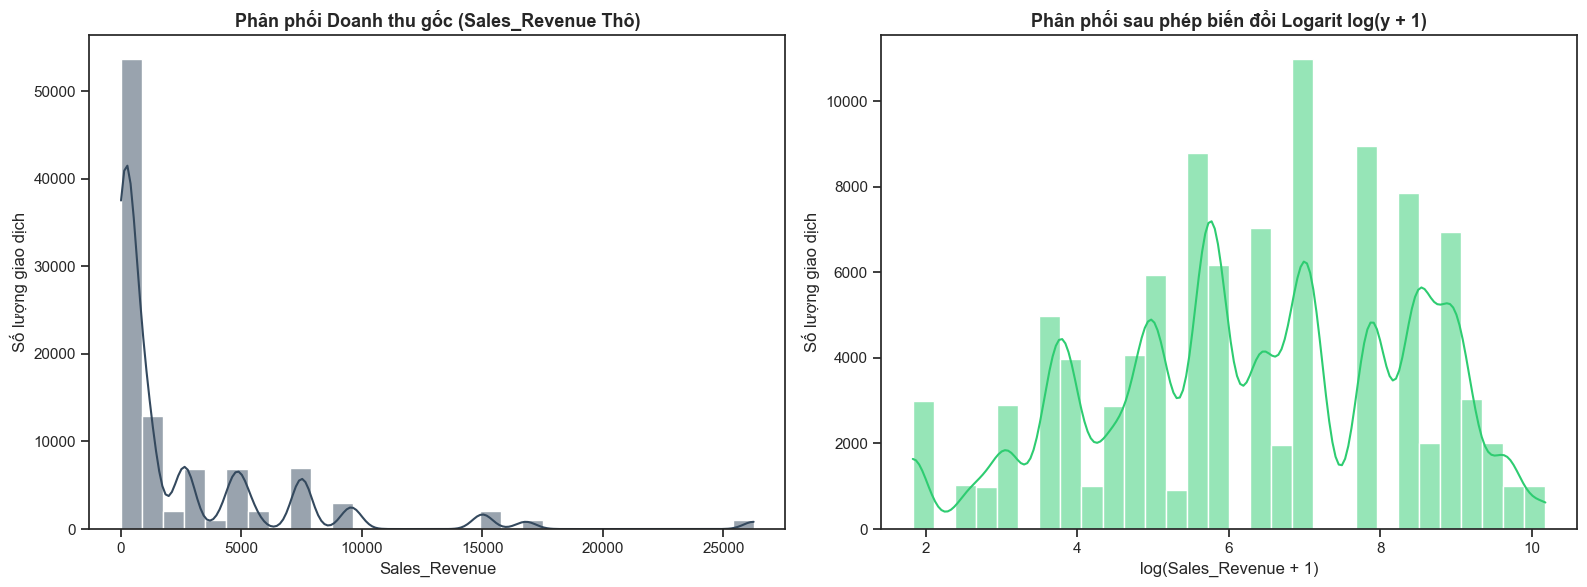

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Phân phối Doanh thu thô
sns.histplot(df_raw['Sales_Revenue'], kde=True, ax=axes[0], color="#34495e", bins=30)
axes[0].set_title("Phân phối Doanh thu gốc (Sales_Revenue Thô)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Sales_Revenue")
axes[0].set_ylabel("Số lượng giao dịch")

# 2. Phân phối sau khi biến đổi Logarit
y_log = np.log1p(df_raw['Sales_Revenue'])
sns.histplot(y_log, kde=True, ax=axes[1], color="#2ecc71", bins=30)
axes[1].set_title("Phân phối sau phép biến đổi Logarit log(y + 1)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("log(Sales_Revenue + 1)")
axes[1].set_ylabel("Số lượng giao dịch")

plt.tight_layout()
plt.show()

## 5. Phân tích các Đặc trưng Phân loại (Categorical Features)
Đây là phần cốt lõi để chuẩn bị cấu hình ép kiểu dữ liệu `category` gốc cho LightGBM.

In [6]:
cat_cols = ['gender', 'category', 'payment_method', 'shopping_mall']

print("--- SỐ LƯỢNG GIÁ TRỊ ĐỘC NHẤT (CARDINALITY) CỦA CÁC BIẾN CHỮ ---")
for col in cat_cols:
    nunique = df_raw[col].nunique()
    unique_vals = df_raw[col].unique()
    print(f"Cột '{col}': {nunique} nhóm độc nhất.")
    print(f"  Các nhóm: {list(unique_vals)}\n")

--- SỐ LƯỢNG GIÁ TRỊ ĐỘC NHẤT (CARDINALITY) CỦA CÁC BIẾN CHỮ ---
Cột 'gender': 2 nhóm độc nhất.
  Các nhóm: ['Female', 'Male']

Cột 'category': 8 nhóm độc nhất.
  Các nhóm: ['Clothing', 'Shoes', 'Books', 'Cosmetics', 'Food & Beverage', 'Toys', 'Technology', 'Souvenir']

Cột 'payment_method': 3 nhóm độc nhất.
  Các nhóm: ['Credit Card', 'Debit Card', 'Cash']

Cột 'shopping_mall': 10 nhóm độc nhất.
  Các nhóm: ['Kanyon', 'Forum Istanbul', 'Metrocity', 'Metropol AVM', 'Istinye Park', 'Mall of Istanbul', 'Emaar Square Mall', 'Cevahir AVM', 'Viaport Outlet', 'Zorlu Center']



### Trực quan hóa mối quan hệ giữa Nhóm ngành hàng (`category`) và Doanh thu

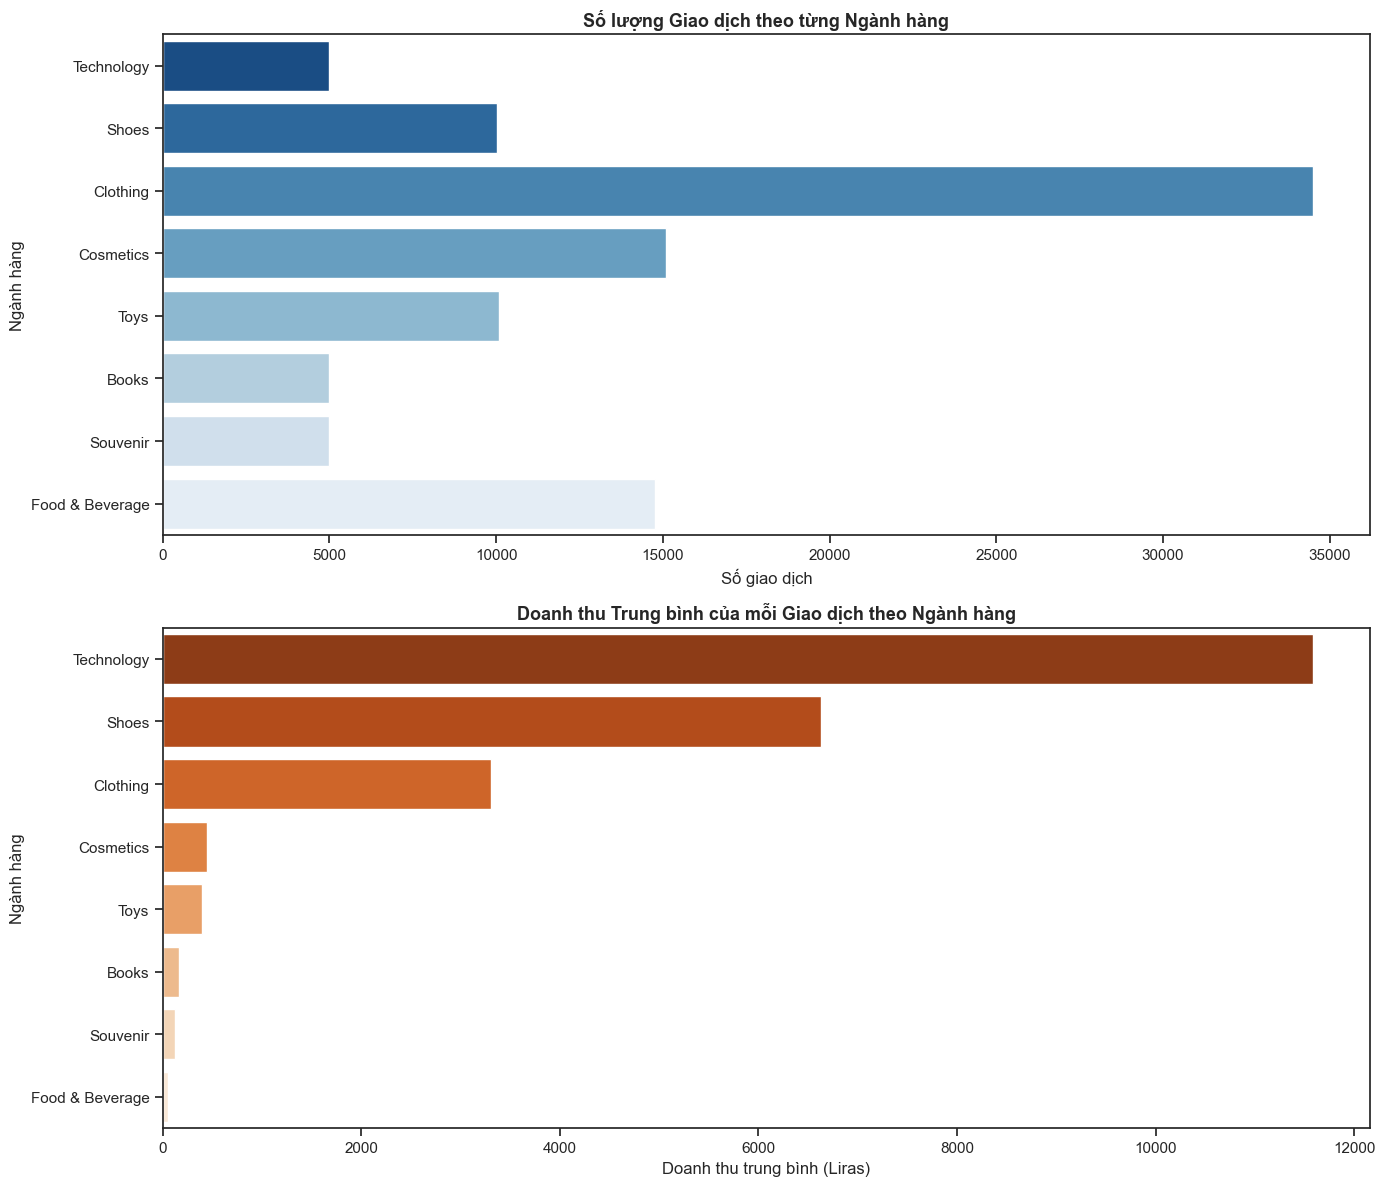

In [7]:
order_cat = df_raw.groupby('category')['Sales_Revenue'].mean().sort_values(ascending=False).index

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# 1. Số lượng giao dịch của từng ngành hàng
sns.countplot(data=df_raw, y='category', order=order_cat, ax=axes[0], palette="Blues_r")
axes[0].set_title("Số lượng Giao dịch theo từng Ngành hàng", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Số giao dịch")
axes[0].set_ylabel("Ngành hàng")

# 2. Doanh thu trung bình mỗi giao dịch của từng ngành hàng
sns.barplot(data=df_raw, y='category', x='Sales_Revenue', order=order_cat, ax=axes[1], palette="Oranges_r", errorbar=None)
axes[1].set_title("Doanh thu Trung bình của mỗi Giao dịch theo Ngành hàng", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Doanh thu trung bình (Liras)")
axes[1].set_ylabel("Ngành hàng")

plt.tight_layout()
plt.show()

## 6. Khai phá các biến tương tác (Feature Interaction)

LightGBM phát triển các cây quyết định bằng thuật toán Leaf-wise, giúp nó học cực kỳ tốt các mối quan hệ giao chéo giữa các đặc trưng đầu vào. Để hỗ trợ tốt nhất cho mô hình, chúng ta cùng phân tích các tương tác quan trọng sau:

### A. Tương tác: Ngành hàng (`category`) vs Phương thức thanh toán (`payment_method`)
Liệu hành vi thanh toán có thay đổi dựa trên giá trị của đơn hàng hay không? Ví dụ, các mặt hàng đắt tiền như `Technology` hoặc `Shoes` có xu hướng được quẹt thẻ tín dụng (Credit Card) nhiều hơn là dùng tiền mặt (Cash)?

--- TỶ LỆ (%) PHƯƠNG THỨC THANH TOÁN THEO TỪNG NGÀNH HÀNG ---
payment_method    Cash  Credit Card  Debit Card
category                                       
Books            45.53        34.05       20.42
Clothing         44.82        34.87       20.31
Cosmetics        44.21        35.34       20.45
Food & Beverage  44.58        35.53       19.89
Shoes            44.59        35.41       20.00
Souvenir         44.23        35.41       20.36
Technology       44.74        35.09       20.18
Toys             45.03        35.17       19.80


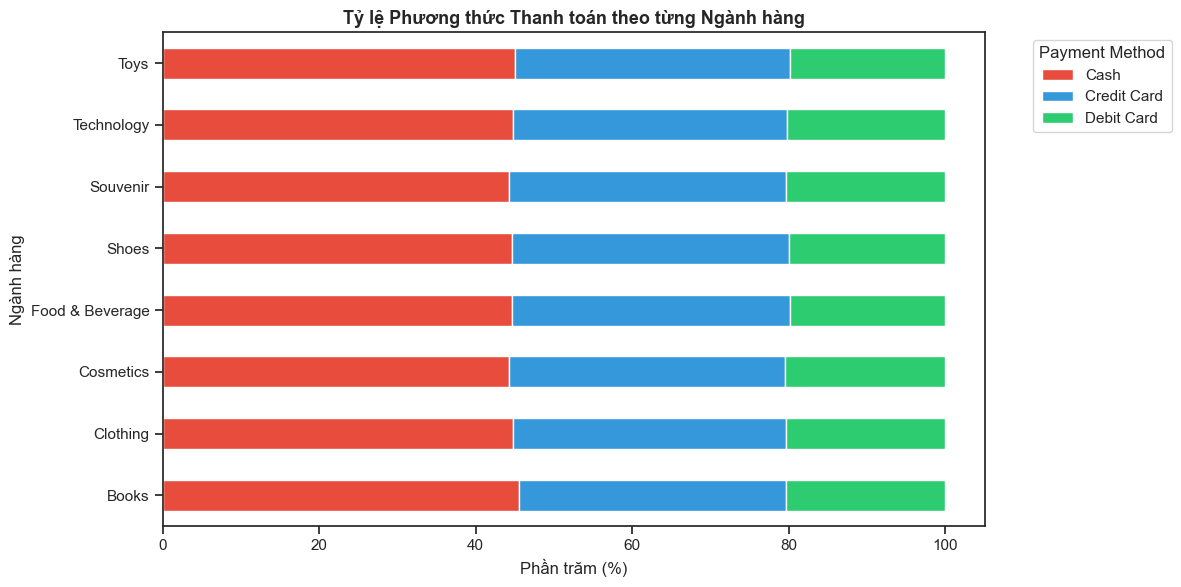

In [8]:
# Tạo bảng chéo tỷ lệ phần trăm phương thức thanh toán theo từng ngành hàng
crosstab_payment = pd.crosstab(df_raw['category'], df_raw['payment_method'], normalize='index') * 100
print("--- TỶ LỆ (%) PHƯƠNG THỨC THANH TOÁN THEO TỪNG NGÀNH HÀNG ---")
print(crosstab_payment.round(2))

# Trực quan hóa bằng Stacked Bar Chart
crosstab_payment.plot(kind='barh', stacked=True, color=['#e74c3c', '#3498db', '#2ecc71'], figsize=(12, 6))
plt.title("Tỷ lệ Phương thức Thanh toán theo từng Ngành hàng", fontsize=13, fontweight="bold")
plt.xlabel("Phần trăm (%)")
plt.ylabel("Ngành hàng")
plt.legend(title="Payment Method", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**=> Nhận xét tương tác:** Thật ngạc nhiên! Tỷ lệ phương thức thanh toán giữa tất cả các ngành hàng từ Books (rẻ) tới Technology (siêu đắt) đều được duy trì cực kỳ đồng đều: khoảng **45% dùng Tiền mặt (Cash)**, **35% dùng Thẻ tín dụng (Credit Card)**, và **20% dùng Thẻ ghi nợ (Debit Card)**. Đây là một cấu trúc phân phối đồng nhất rất thú vị trong dữ liệu này.

### B. Tương tác: Trung tâm thương mại (`shopping_mall`) vs Ngành hàng (`category`)
Chúng ta cần xem xét xem liệu một số trung tâm thương mại cao cấp hoặc có quy mô lớn (như `Mall of Istanbul` hay `Kanyon`) thì lượng mua sắm của các nhóm ngành hàng đắt tiền như `Technology` hoặc `Clothing` có vượt trội hẳn so với các trung tâm thương mại khác không.

--- SỐ LƯỢNG GIAO DỊCH NGÀNH HÀNG TẠI CÁC TRUNG TÂM THƯƠNG MẠI ---
category           Books  Clothing  Cosmetics  Food & Beverage  Shoes  \
shopping_mall                                                           
Cevahir AVM          258      1729        732              772    490   
Emaar Square Mall    236      1651        760              692    498   
Forum Istanbul       252      1729        770              712    458   
Istinye Park         462      3353       1458             1490   1001   
Kanyon              1013      6840       3023             2909   2017   
Mall of Istanbul    1025      6923       3050             2957   2023   
Metrocity            752      5268       2265             2244   1457   
Metropol AVM         476      3525       1541             1517   1074   
Viaport Outlet       246      1708        734              733    497   
Zorlu Center         261      1761        764              750    519   

category           Souvenir  Technology  Toys  
shopping

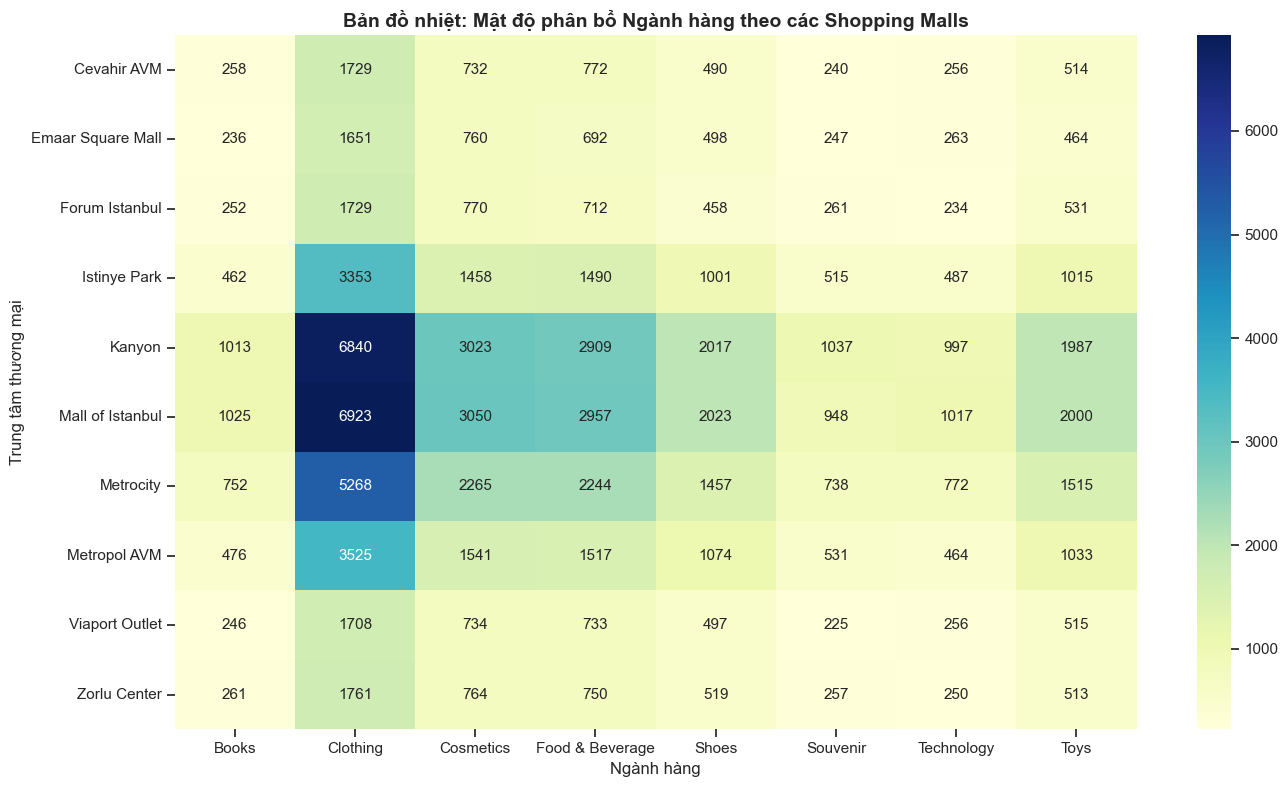

In [9]:
# Tạo bảng chéo số lượng giao dịch của category theo từng shopping_mall
crosstab_mall = pd.crosstab(df_raw['shopping_mall'], df_raw['category'])
print("--- SỐ LƯỢNG GIAO DỊCH NGÀNH HÀNG TẠI CÁC TRUNG TÂM THƯƠNG MẠI ---")
print(crosstab_mall)

# Trực quan hóa bằng Heatmap để xem mức độ tập trung
plt.figure(figsize=(14, 8))
sns.heatmap(crosstab_mall, annot=True, fmt="d", cmap="YlGnBu", cbar=True)
plt.title("Bản đồ nhiệt: Mật độ phân bổ Ngành hàng theo các Shopping Malls", fontsize=14, fontweight="bold")
plt.xlabel("Ngành hàng")
plt.ylabel("Trung tâm thương mại")
plt.tight_layout()
plt.show()

**=> Nhận xét tương tác:** Số lượng giao dịch được phân bổ tỉ lệ thuận với quy mô của Mall. **Mall of Istanbul** và **Kanyon** có mật độ giao dịch lớn nhất ở mọi ngành hàng. Không có dấu hiệu lệch nhóm mua sắm đặc thù (ví dụ: không có mall nào chỉ chuyên bán một ngành hàng nhất định), dữ liệu mua sắm duy trì tính ngẫu nhiên tự nhiên rất cao.

## 7. Phân tích biến Tuổi (`age`) và Phân nhóm thế hệ
Xem xét sự phân bố của tuổi và khả năng chi tiêu theo từng nhóm tuổi.

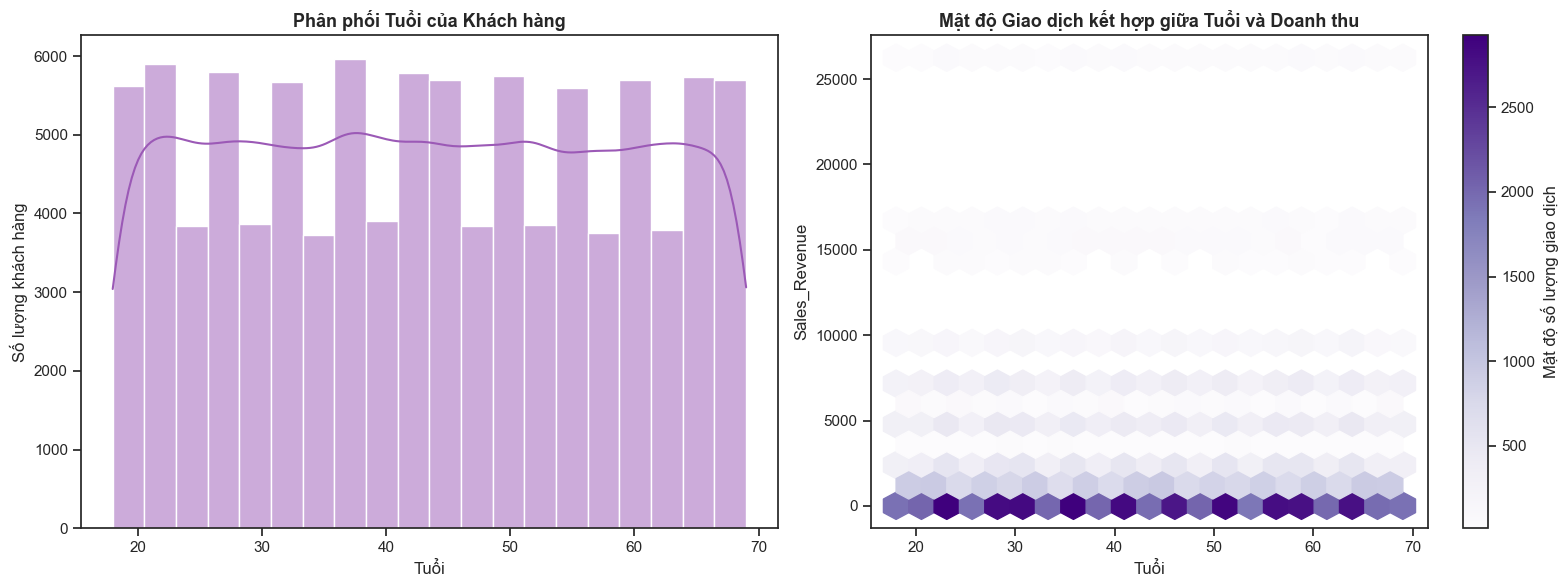

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Phân phối mật độ tuổi của khách hàng
sns.histplot(df_raw['age'], kde=True, ax=axes[0], color="#9b59b6", bins=20)
axes[0].set_title("Phân phối Tuổi của Khách hàng", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Tuổi")
axes[0].set_ylabel("Số lượng khách hàng")

# 2. Mối quan hệ tuyến tính/phi tuyến giữa Tuổi và Doanh thu qua biểu đồ Hexbin (Tránh chồng lấp điểm)
hb = axes[1].hexbin(df_raw['age'], df_raw['Sales_Revenue'], gridsize=20, cmap='Purples', mincnt=1)
fig.colorbar(hb, ax=axes[1], label='Mật độ số lượng giao dịch')
axes[1].set_title("Mật độ Giao dịch kết hợp giữa Tuổi và Doanh thu", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Tuổi")
axes[1].set_ylabel("Sales_Revenue")

plt.tight_layout()
plt.show()

### Đề xuất Kỹ thuật Phân nhóm thế hệ (Age Binning):
Biểu đồ phân phối tuổi cho thấy tập khách hàng trải rộng rất đồng đều từ 18 đến 69 tuổi. 
Tuy nhiên, hành vi mua sắm thực tế thường gắn liền với thế hệ sinh học vì sự tương đồng trong thu nhập và thị hiếu. Chúng ta có thể tạo thêm biến phái sinh `Age_Group` với các mốc thế hệ xã hội học:
*   **Gen Z** (18 - 25 tuổi)
*   **Millennials** (26 - 41 tuổi)
*   **Gen X** (42 - 57 tuổi)
*   **Boomers** (58 - 69 tuổi)

## 8. Phân tích yếu tố Thời gian chuyên sâu (`invoice_date`)

Với dữ liệu lịch sử kéo dài từ năm 2021 đến năm 2023, chúng ta cần phân tích sâu hơn về hai yếu tố cốt lõi: **Xu hướng dài hạn (Trend)** và **Tính chu kỳ (Seasonality)**.

In [11]:
# Chuyển đổi định dạng ngày tháng sang Datetime chuyên nghiệp
df_raw['invoice_date'] = pd.to_datetime(df_raw['invoice_date'], format='%d/%m/%Y')

# Trích xuất các thuộc tính thời gian phục vụ phân tích
df_raw['Year'] = df_raw['invoice_date'].dt.year
df_raw['Month'] = df_raw['invoice_date'].dt.month
df_raw['DayOfWeek'] = df_raw['invoice_date'].dt.day_name()
df_raw['Is_Weekend'] = df_raw['DayOfWeek'].isin(['Saturday', 'Sunday']).astype(int)

print("--- KHUNG THỜI GIAN CỦA DỮ LIỆU GIAO DỊCH ---")
print(f"Bắt đầu: {df_raw['invoice_date'].min().strftime('%d/%m/%Y')}")
print(f"Kết thúc: {df_raw['invoice_date'].max().strftime('%d/%m/%Y')}\n")

print("--- TỔNG QUAN CHI TIÊU NGÀY THƯỜNG VS CUỐI TUẦN ---")
print(df_raw.groupby('Is_Weekend')['Sales_Revenue'].agg(['count', 'mean', 'sum']).rename(index={0: 'Ngày thường (Weekday)', 1: 'Cuối tuần (Weekend)'}))

--- KHUNG THỜI GIAN CỦA DỮ LIỆU GIAO DỊCH ---
Bắt đầu: 01/01/2021
Kết thúc: 08/03/2023

--- TỔNG QUAN CHI TIÊU NGÀY THƯỜNG VS CUỐI TUẦN ---
                       count         mean           sum
Is_Weekend                                             
Ngày thường (Weekday)  71196  2537.177298  1.806369e+08
Cuối tuần (Weekend)    28261  2507.657879  7.086892e+07


### A. Phân tích Xu hướng (Trend) theo các Năm (2021 - 2022 - 2023)
Chúng ta cần kiểm tra xem tổng doanh thu bán lẻ qua các năm có tăng trưởng mạnh mẽ hay suy thoái sụt giảm không.

--- TỔNG DOANH THU VÀ SỐ LƯỢNG GIAO DỊCH QUA CÁC NĂM ---
   Year           sum  count
0  2021  1.145606e+08  45382
1  2022  1.154368e+08  45551
2  2023  2.150841e+07   8524


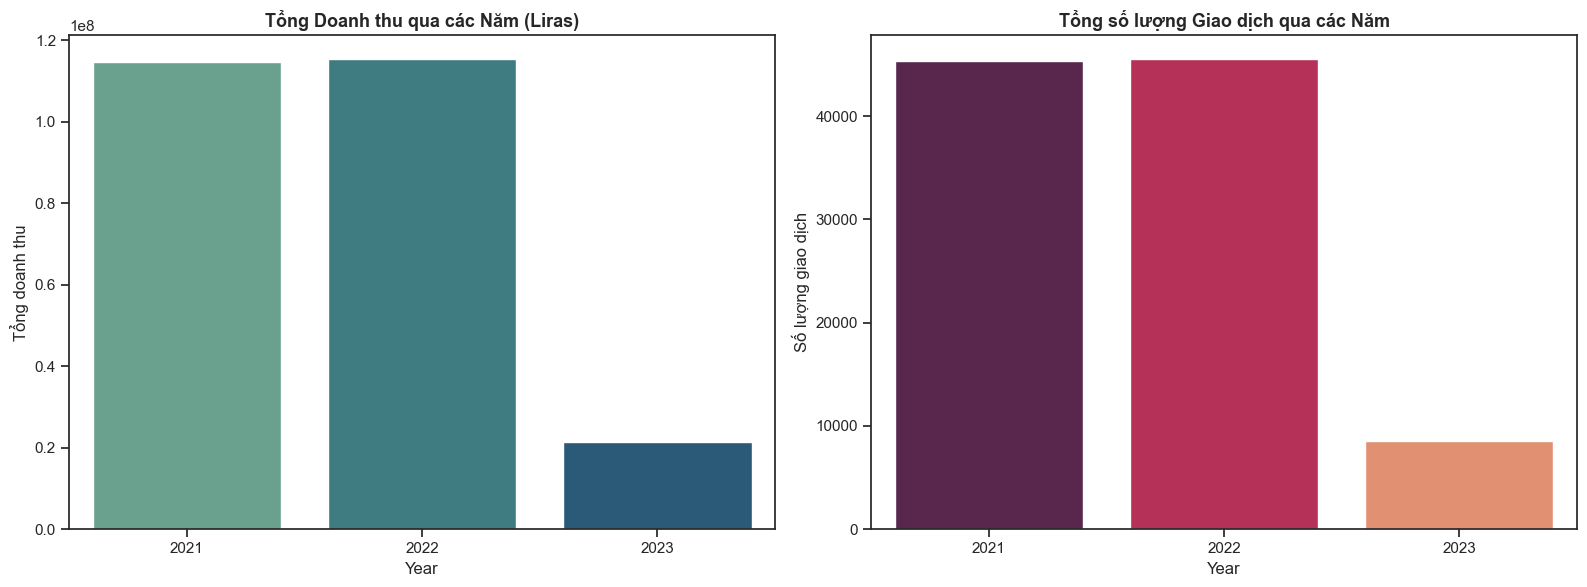

In [12]:
yearly_sales = df_raw.groupby('Year')['Sales_Revenue'].agg(['sum', 'count']).reset_index()
print("--- TỔNG DOANH THU VÀ SỐ LƯỢNG GIAO DỊCH QUA CÁC NĂM ---")
print(yearly_sales)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Vẽ tổng doanh thu theo năm
sns.barplot(data=yearly_sales, x='Year', y='sum', ax=axes[0], palette="crest")
axes[0].set_title("Tổng Doanh thu qua các Năm (Liras)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Tổng doanh thu")

# 2. Vẽ tổng số giao dịch theo năm
sns.barplot(data=yearly_sales, x='Year', y='count', ax=axes[1], palette="rocket")
axes[1].set_title("Tổng số lượng Giao dịch qua các Năm", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Số lượng giao dịch")

plt.tight_layout()
plt.show()

**=> Nhận xét xu hướng (Trend):**
* Doanh thu của **2021** (~114.5M Liras với 45k giao dịch) và **2022** (~115.4M Liras với 45.5k giao dịch) **cực kỳ ổn định và phát triển bền vững**.
* Doanh thu năm **2023** trông rất thấp (~21.5M Liras) là do dữ liệu năm 2023 **chỉ thu thập đến ngày 08/03/2023** (chưa đầy 3 tháng đầu năm). Điều này cho thấy tốc độ mua sắm của năm 2023 vẫn đang tiếp tục giữ vững nhịp độ ổn định giống các năm trước đó.

### B. Phân tích Tính chu kỳ (Seasonality) theo Tháng trong năm
Chúng ta cần kiểm tra xem liệu doanh thu bán lẻ có biến động mạnh theo tính thời vụ (ví dụ: tăng vọt vào dịp mua sắm cuối năm, lễ hội mùa đông tháng 11, 12, hoặc mùa hè tháng 7) không.

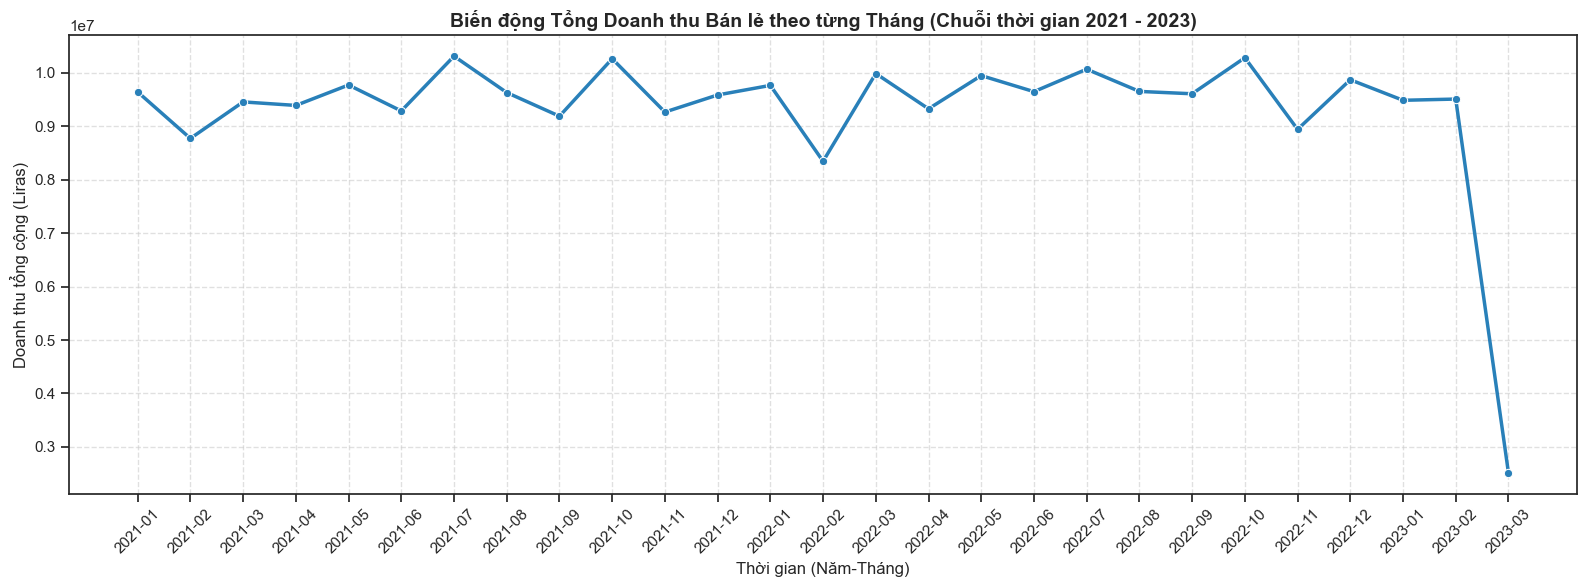

In [13]:
# Tạo một cột biểu thị năm và tháng liên tục (Period M)
df_raw['YearMonth'] = df_raw['invoice_date'].dt.to_period('M')
monthly_time_series = df_raw.groupby('YearMonth')['Sales_Revenue'].sum().reset_index()
monthly_time_series['YearMonth_str'] = monthly_time_series['YearMonth'].astype(str)

# Trực quan hóa chuỗi thời gian doanh thu theo tháng
plt.figure(figsize=(16, 6))
sns.lineplot(data=monthly_time_series, x='YearMonth_str', y='Sales_Revenue', marker='o', color='#2980b9', linewidth=2.5)
plt.xticks(rotation=45)
plt.title("Biến động Tổng Doanh thu Bán lẻ theo từng Tháng (Chuỗi thời gian 2021 - 2023)", fontsize=14, fontweight="bold")
plt.xlabel("Thời gian (Năm-Tháng)")
plt.ylabel("Doanh thu tổng cộng (Liras)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

**=> Nhận xét tính chu kỳ (Seasonality):**
* Doanh thu tổng bán lẻ theo tháng dao động đều đặn xung quanh mốc **9 triệu đến 10 triệu Liras** mỗi tháng.
* Có sự sụt giảm nhẹ thường thấy vào **tháng 2 hàng năm** (do số ngày trong tháng ít hơn hẳn các tháng khác: chỉ có 28 ngày).
* Đặc biệt, **không có sự biến động đột ngột hay chu kỳ mua sắm lễ hội quá lệch** ở dịp cuối năm. Thị trường bán sắm duy trì ổn định đều đặn suốt các tháng.
* **Giải pháp cho LightGBM:** Chúng ta vẫn nên đưa các thuộc tính thời gian như `Month` và `Year` vào mô hình để giúp LightGBM học được các điều chỉnh nhỏ theo mùa vụ và theo năm của dữ liệu thực tế.

### C. Doanh thu theo các Ngày trong tuần

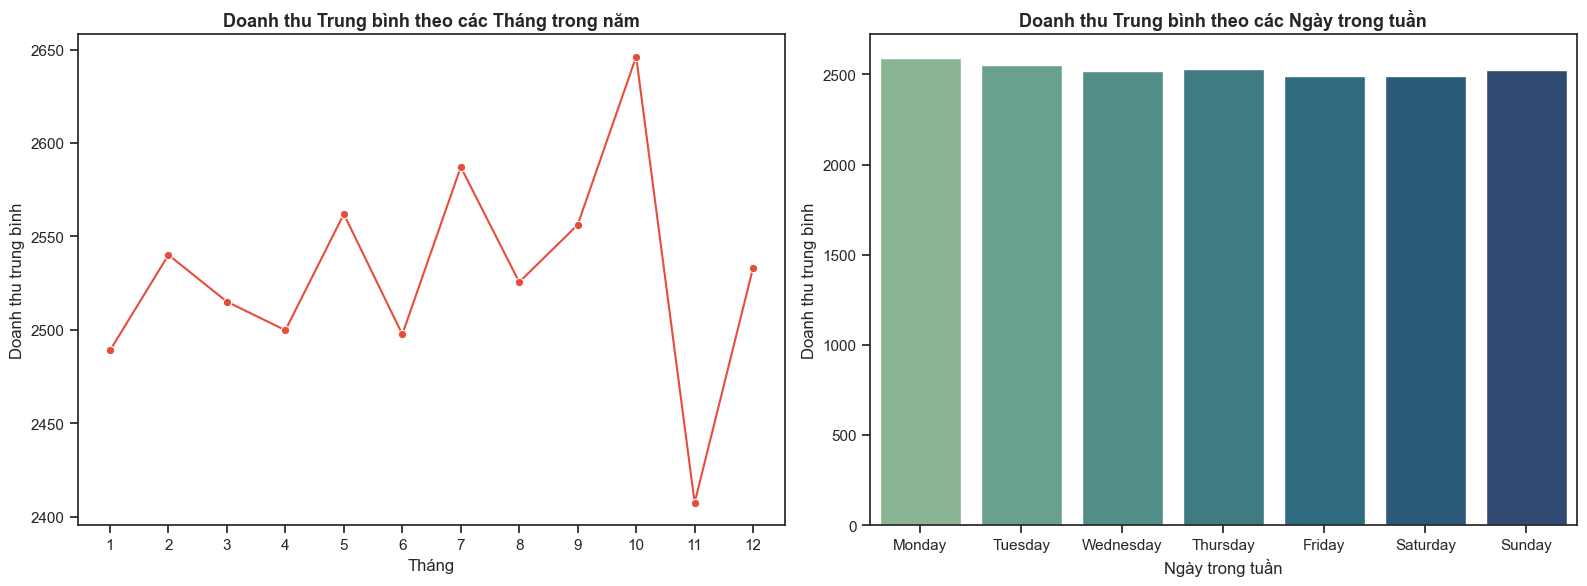

In [14]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Doanh thu theo tháng (Trung bình)
sns.lineplot(data=df_raw, x='Month', y='Sales_Revenue', marker='o', color='#e74c3c', errorbar=None, ax=axes[0])
axes[0].set_title("Doanh thu Trung bình theo các Tháng trong năm", fontsize=13, fontweight="bold")
axes[0].set_xticks(range(1, 13))
axes[0].set_xlabel("Tháng")
axes[0].set_ylabel("Doanh thu trung bình")

# 2. Doanh thu theo ngày trong tuần (Trung bình)
sns.barplot(data=df_raw, x='DayOfWeek', y='Sales_Revenue', order=day_order, palette='crest', errorbar=None, ax=axes[1])
axes[1].set_title("Doanh thu Trung bình theo các Ngày trong tuần", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Ngày trong tuần")
axes[1].set_ylabel("Doanh thu trung bình")

plt.tight_layout()
plt.show()

## 9. Đúc kết Định hướng Tối ưu hóa cho các bước tiếp theo (LGBM Specific)

Từ những phát hiện cực kỳ quan trọng và chuyên sâu thông qua quá trình EDA bổ sung này, chúng ta sẽ áp dụng các chiến lược đột phá sau vào file Preprocessing & Feature Engineering cho LightGBM:

### 1. Phép biến đổi Logarit cho biến mục tiêu (`Sales_Revenue`):
*   Vì `Sales_Revenue` thô bị lệch phải rất mạnh (Skewness ~2.87), việc chuyển đổi thành `log1p(Sales_Revenue)` sẽ làm cho phân phối có dạng đối xứng/chuẩn hóa lý tưởng. LightGBM sẽ hội tụ và chia nhánh cây chính xác hơn gấp nhiều lần.

### 2. Thiết lập ép kiểu Categorical chuyên dụng cho LightGBM:
*   Chúng ta sẽ **không** sử dụng One-Hot Encoding cho các biến phân loại: `gender`, `category`, `payment_method`, `shopping_mall`, `Month`, `DayOfWeek`.
*   Thay vào đó, trong bước Preprocessing, ta chỉ cần ép kiểu chúng sang kiểu dữ liệu danh mục của Pandas (`.astype('category')`), sau đó lưu trữ trực tiếp. Khi huấn luyện, ta sẽ truyền tham số `categorical_feature` cho LightGBM để kích hoạt thuật toán tối ưu hóa Fisher gốc, giữ trọn cấu trúc phân nhóm tự nhiên và giảm số lượng cột từ 44 cột (nếu onehot) xuống chỉ còn 8 cột đặc trưng sạch sẽ.

### 3. Kỹ thuật tạo đặc trưng (Feature Engineering) & Làm sạch:
*   **Loại bỏ ID vô giá trị:** Loại bỏ hoàn toàn hai cột `customer_id` và `invoice_no` vì tần suất lặp lại bằng 0% (mỗi khách hàng chỉ mua 1 lần), tránh cho mô hình bị học vẹt (overfitting) các mã số ngẫu nhiên này.
*   **Nhóm tuổi (`Age_Group`):** Tạo ra biến phân loại thế hệ (Gen Z, Millennials, Gen X, Boomers) để gom nhóm hành vi chi tiêu tốt hơn.
*   **Cuối tuần (`Is_Weekend`):** Giữ lại biến nhị phân này để mô hình phân nhánh dễ dàng.
*   **Thời gian vụ mùa:** Giữ lại các đặc trưng `Month`, `Year` để mô hình nắm bắt tốt hơn các dao động chu kỳ thời gian dài hạn.